In [159]:
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.metrics import precision_score, accuracy_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier

In [160]:
shop_data = pd.read_csv("shop_smart_ecommerce.csv")

shop_data.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [161]:
shop_data = pd.get_dummies(data=shop_data, columns=["VisitorType", "Month"], drop_first=True, dtype=int)

shop_data["Weekend"] = shop_data["Weekend"].astype(int)
shop_data["Revenue"] = shop_data["Revenue"].astype(int)

shop_data.fillna(shop_data.median(), inplace=True)
shop_data.fillna("Unknown", inplace=True)



In [162]:
X = shop_data.drop("Revenue", axis=1)
y = shop_data["Revenue"]

In [163]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [197]:
max_depths = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11,12]

best_f1 = 0
best_depth = 2
for depth in max_depths:
    model = DecisionTreeClassifier(max_depth=depth, max_leaf_nodes=70)
    model.fit(X_train, y_train)

    X_pred = model.predict(X_train)
    f1_scores = f1_score(y_train, X_pred)
    print(f"for depth={depth}, f1={f1_scores}")

    if f1_scores > best_f1:
        best_f1 = f1_scores
        best_depth = depth


print("best_depth = ", best_depth) 
print("f1 = ", best_f1)     

for depth=2, f1=0.5777166437414031
for depth=3, f1=0.66268418956591
for depth=4, f1=0.6400359066427289
for depth=5, f1=0.6755364806866953
for depth=6, f1=0.7031578947368421
for depth=7, f1=0.7301587301587301
for depth=8, f1=0.7362366474938373
for depth=9, f1=0.7513899920571883
for depth=10, f1=0.7589214908802537
for depth=11, f1=0.7493775933609959
for depth=12, f1=0.7488584474885844
best_depth =  10
f1 =  0.7589214908802537


In [202]:
model = DecisionTreeClassifier(
    max_depth=10,
    max_leaf_nodes=70,
    random_state=0, 
    class_weight="balanced"
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("f1 score: ", f1_score(y_test, y_pred))

f1 score:  0.6234446627373936


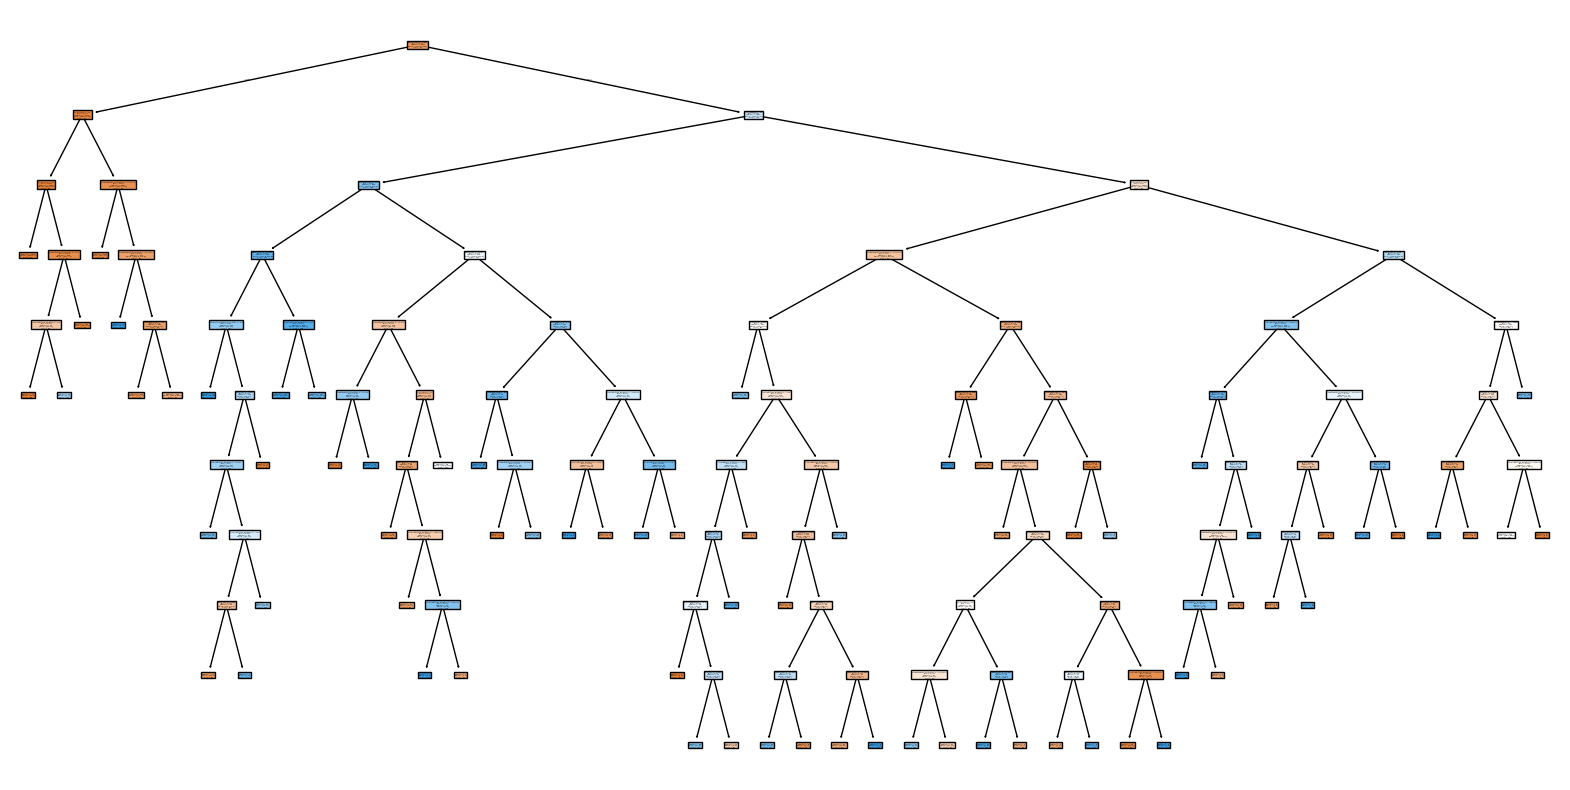

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    model,               
    feature_names=X.columns,
    class_names=["No", "Yes"],   
    filled=True
)

plt.show()